## Climate Zones - Data Exploration
* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-02-10
* © British Crown Copyright 2017-2065, Met Office. Please see LICENSE.md for license details.

Author - Stephen Haddad


## Overview of the broad topic covered


The climate of different areas of the world is classified into different types, based on the Koppen-Geiger scheme. As the climate changes, some areas may change the classification of their climate 
In this series of tutorial notebooks, we willlearn how to build a machine learning pipeline by building a model to predict the clinate zone of a location from key climate means and indicators. We will look at how climate models predict shifts in the classification of climate zones as the climate changes in the future.

Links
 - [Climate Zones- Wikipedia](https://en.wikipedia.org/wiki/K%C3%B6ppen_climate_classification)
 - [CLimate Zones Dataset](https://www.gloh2o.org/koppen/#:~:text=The%20K%C3%B6ppen%2DGeiger%20climate%20classification%20maps%20are%20high%2Dresolution,Climate%20Sensitivity%20(ECS)%2C%20and%20historical%20warming%20trend) 
    

### Prerequisites 
what background information is needed to go through the notebook


### Learning outcomes from completing the notebook

## Tutorial 
a balance of explanation and activity



In [1]:
import pathlib
import os

In [2]:
import matplotlib.pyplot
import cartopy.crs

In [3]:
import xarray

#### Dataset parameters

In [16]:
def get_platform_dir(select_platform):
    if select_platform == 'mo_linux':
      return pathlib.Path(os.environ['DATADIR']) / 'climate_zones'
    if select_platform == 'jasmin':
        return pathlib.Path('/gws/nopw/j04/mohc_shared/dscop/') / 'climate_zones'
    print('platform not found, return generic path')
    return pathlib.Path(os.environ['HOME']) / 'climate_zones',

current_platform = 'mo_linux'

In [17]:
root_data_dir = get_platform_dir(current_platform)

print(root_data_dir.is_dir())
root_data_dir

True


PosixPath('/data/users/stephen.haddad/climate_zones')

In [18]:
resolutions_dict = {
    0.1: '0p1',
    0.5: '0p5',
    1.0: '1p0',
}

dataset_prefix_dict = {
    'climate_mean': 'ensemble_mean',
    'climate_std': 'ensemble_std',
    'climate_zone': 'koppen_geiger',
    
}
format_str = 'nc'
historic_scenario_str = 'historic'

future_scenario_list = ['ssp119','ssp126','ssp245','ssp370','ssp434','ssp460','ssp585']
historic_scenario_list = [historic_scenario_str,]

time_periods = { 
    (1901,1930): historic_scenario_list, 
    (1931,1960): historic_scenario_list,
    (1961,1990): historic_scenario_list,
    (1991,2020): historic_scenario_list,
    (2041,2070): future_scenario_list,
    (2071,2099): future_scenario_list,
}


In [19]:
fname_template = '{prefix}_{res}.{suffix}'
time_dir_template = '{start_year}_{end_year}'

In [20]:
zones = [
]

The following lables for climate zones are taken from the `legends.txt` file in the [dataset](https://figshare.com/articles/dataset/High-resolution_1_km_K_ppen-Geiger_maps_for_1901_2099_based_on_constrained_CMIP6_projections/21789074)

In [21]:
climate_zones_lookup = [
    ('non-land','None'), #this corresponds to the zero in the data. Will be filtered out of training data.
    ('Af','Tropical, rainforest'),
    ('Am','Tropical, monsoon'),
    ('Aw','Tropical, savannah'),
    ('BWh','Arid, desert, hot'),
    ('BWk','Arid, desert, cold'),
    ('BSh','Arid, steppe, hot'),
    ('BSk','Arid, steppe, cold'),
    ('Csa','Temperate, dry summer, hot summer'),
    ('Csb','Temperate, dry summer, warm summer'),
    ('Csc','Temperate, dry summer, cold summer'),
    ('Cwa','Temperate, dry winter, hot summer'),
    ('Cwb','Temperate, dry winter, warm summer'),
    ('Cwc','Temperate, dry winter, cold summer'),
    ('Cfa','Temperate, no dry season, hot summer'),
    ('Cfb','Temperate, no dry season, warm summer'),
    ('Cfc','Temperate, no dry season, cold summer'),
    ('Dsa','Cold, dry summer, hot summer'),
    ('Dsb','Cold, dry summer, warm summer'),
    ('Dsc','Cold, dry summer, cold summer'),
    ('Dsd','Cold, dry summer, very cold winter'),
    ('Dwa','Cold, dry winter, hot summer'),
    ('Dwb','Cold, dry winter, warm summer'),
    ('Dwc','Cold, dry winter, cold summer'),
    ('Dwd','Cold, dry winter, very cold winter'),
    ('Dfa','Cold, no dry season, hot summer'),
    ('Dfb','Cold, no dry season, warm summer'),
    ('Dfc','Cold, no dry season, cold summer'),
    ('Dfd'',Cold, no dry season, very cold winter'),
    ('ET','Polar, tundra'),
    ('EF','Polar, frost'),
]

For comparison we will try predicting all 30 zones, but also trying to predict the five zone groupings for a simpler problem.

In [22]:
major_zones_dict = {
    'A': range(1,4),
    'B': range(4,8),
    'C': range(8,17),
    'D': range(17,29),
    'E': range(29,31),
}

In [23]:
zones_grouping_lut = [0 for i1 in range (31)]
for ix1, (grouping, group_indices) in enumerate(major_zones_dict.items()):
    for zone_index in group_indices:
        zones_grouping_lut[zone_index] = ix1+1
        

### Load the data

In [24]:
def get_data_path(root_dir, time_period, scenario_id, prefix, resolution, suffix) :
    start_year = time_period[0]
    end_year = time_period[1]
    if scenario_id == historic_scenario_str:
        data_dir = root_data_dir / time_dir_template.format(start_year=start_year,end_year=end_year)
    else:
        data_dir = root_data_dir / time_dir_template.format(start_year=start_year,end_year=end_year) / scenario_id 
    data_fname = fname_template.format(prefix=prefix, 
                                       res=resolutions_dict[current_res], 
                                       suffix=format_str)
    return data_dir / data_fname

In [25]:
current_res = 1.0

In [26]:
data_path_dict = {
    (start_year, end_year): {
        scenario_id: { ds_id: get_data_path(root_dir=root_data_dir,
                                            time_period=(start_year, end_year),
                                            scenario_id=scenario_id, 
                                            prefix=ds_str,
                                            resolution=current_res,
                                            suffix=format_str,
                                           )
                       for ds_id, ds_str in dataset_prefix_dict.items()
                     } 
        for scenario_id in current_scenarios
    }
    for (start_year, end_year), current_scenarios in time_periods.items()                                                                                                             
}

In [27]:
with open('/gws/nopw/j04/mohc_shared/dscop/climate_zones/legend.txt') as f1:
    zones_legend = f1.readlines()
print(''.join(zones_legend))


FileNotFoundError: [Errno 2] No such file or directory: '/gws/nopw/j04/mohc_shared/dscop/climate_zones/legend.txt'

In [28]:
for cp, ps in data_path_dict.items():
    for sid, pd in ps.items():
        for ds_id, ds_path in pd.items():
            print(cp, ds_id, ds_path.is_file())
data_path_dict

(1901, 1930) climate_mean True
(1901, 1930) climate_std True
(1901, 1930) climate_zone True
(1931, 1960) climate_mean True
(1931, 1960) climate_std True
(1931, 1960) climate_zone True
(1961, 1990) climate_mean True
(1961, 1990) climate_std True
(1961, 1990) climate_zone True
(1991, 2020) climate_mean True
(1991, 2020) climate_std True
(1991, 2020) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climate_zone True
(2041, 2070) climate_mean True
(2041, 2070) climate_std True
(2041, 2070) climat

{(1901,
  1930): {'historic': {'climate_mean': PosixPath('/data/users/stephen.haddad/climate_zones/1901_1930/ensemble_mean_1p0.nc'),
   'climate_std': PosixPath('/data/users/stephen.haddad/climate_zones/1901_1930/ensemble_std_1p0.nc'),
   'climate_zone': PosixPath('/data/users/stephen.haddad/climate_zones/1901_1930/koppen_geiger_1p0.nc')}},
 (1931,
  1960): {'historic': {'climate_mean': PosixPath('/data/users/stephen.haddad/climate_zones/1931_1960/ensemble_mean_1p0.nc'),
   'climate_std': PosixPath('/data/users/stephen.haddad/climate_zones/1931_1960/ensemble_std_1p0.nc'),
   'climate_zone': PosixPath('/data/users/stephen.haddad/climate_zones/1931_1960/koppen_geiger_1p0.nc')}},
 (1961,
  1990): {'historic': {'climate_mean': PosixPath('/data/users/stephen.haddad/climate_zones/1961_1990/ensemble_mean_1p0.nc'),
   'climate_std': PosixPath('/data/users/stephen.haddad/climate_zones/1961_1990/ensemble_std_1p0.nc'),
   'climate_zone': PosixPath('/data/users/stephen.haddad/climate_zones/1961_19

We'll start by loading the three parts to the data for the historical period 1901 to 1930.

In [29]:
data_dict = {
    current_period: {
        scenario_id: {ds_id: xarray.open_dataset(current_path) for ds_id, current_path in ds_dict.items()} for scenario_id, ds_dict in data_path_dict[current_period].items()
    } for current_period in [(1901,1930), (2071,2099)]
}

In [30]:
data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_mean'].loc[{'time':1.0}]

<xarray.Dataset> Size: 523kB
Dimensions:          (lat: 180, lon: 360)
Coordinates:
  * lat              (lat) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon              (lon) float64 3kB -179.5 -178.5 -177.5 ... 178.5 179.5
    time             float64 8B 1.0
Data variables:
    precipitation    (lat, lon) float32 259kB ...
    air_temperature  (lat, lon) float32 259kB ...
Attributes:
    history:  Created on 2025-10-21 05:47

In [31]:
data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_zone']

<xarray.Dataset> Size: 523kB
Dimensions:        (lat: 180, lon: 360)
Coordinates:
  * lat            (lat) float64 1kB 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * lon            (lon) float64 3kB -179.5 -178.5 -177.5 ... 177.5 178.5 179.5
Data variables:
    kg_class       (lat, lon) float32 259kB ...
    kg_confidence  (lat, lon) float32 259kB ...
Attributes:
    history:  Created on 2025-10-21 06:26

In [32]:
data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_zone']['kg_class']

<xarray.DataArray 'kg_class' (lat: 180, lon: 360)> Size: 259kB
[64800 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 1kB 89.5 88.5 87.5 86.5 ... -86.5 -87.5 -88.5 -89.5
  * lon      (lon) float64 3kB -179.5 -178.5 -177.5 -176.5 ... 177.5 178.5 179.5
Attributes:
    units:

Text(0.5, 1.0, 'KG CLimate Zones (1901, 1930)')

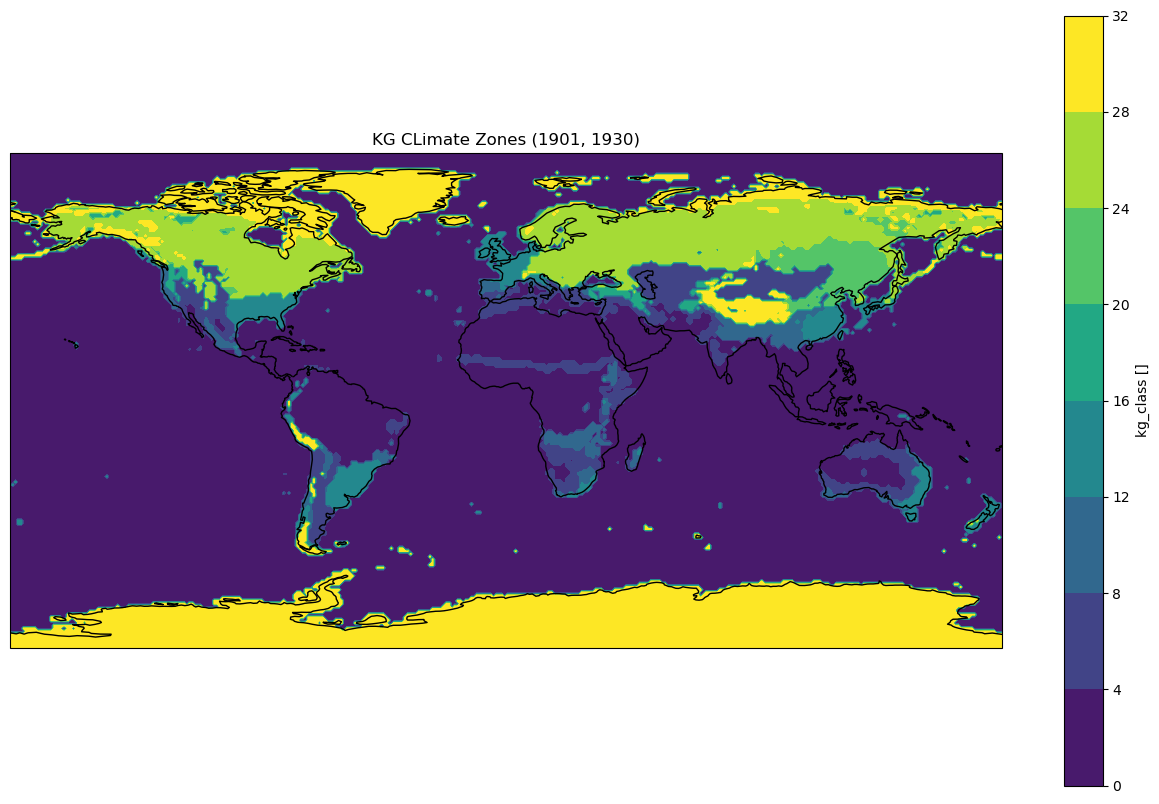

In [33]:
fig1 = matplotlib.pyplot.figure(figsize=(16,10))

ax1 = fig1.add_subplot(1,1,1 ,projection=cartopy.crs.PlateCarree(),)
plot_ds = data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_zone']['kg_class']
plot_ds.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree()) 
ax1.coastlines()
ax1.set_title(f'KG CLimate Zones {list(time_periods.keys())[0]}')

In [34]:
#todo: apply zoes grouping and visualise.

(array([3.9172e+04, 1.2380e+03, 6.6100e+02, 1.7570e+03, 2.0400e+03,
        6.3200e+02, 7.3400e+02, 8.3200e+02, 2.7200e+02, 1.9500e+02,
        0.0000e+00, 4.0800e+02, 1.6600e+02, 0.0000e+00, 6.9800e+02,
        5.0600e+02, 4.7000e+01, 2.2000e+01, 1.1200e+02, 1.6700e+02,
        1.1000e+01, 1.4000e+02, 1.7400e+02, 4.0700e+02, 7.9000e+01,
        2.1900e+02, 1.2300e+03, 2.8840e+03, 2.0900e+02, 9.7880e+03]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
        13., 14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25.,
        26., 27., 28., 29., 30.]),
 <BarContainer object of 30 artists>)

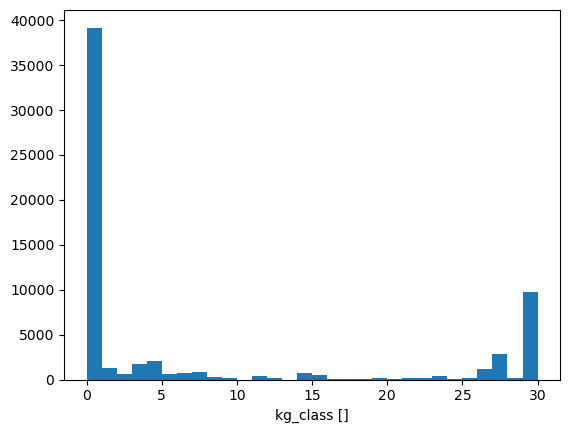

In [35]:
data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_zone']['kg_class'].plot.hist(bins=30)

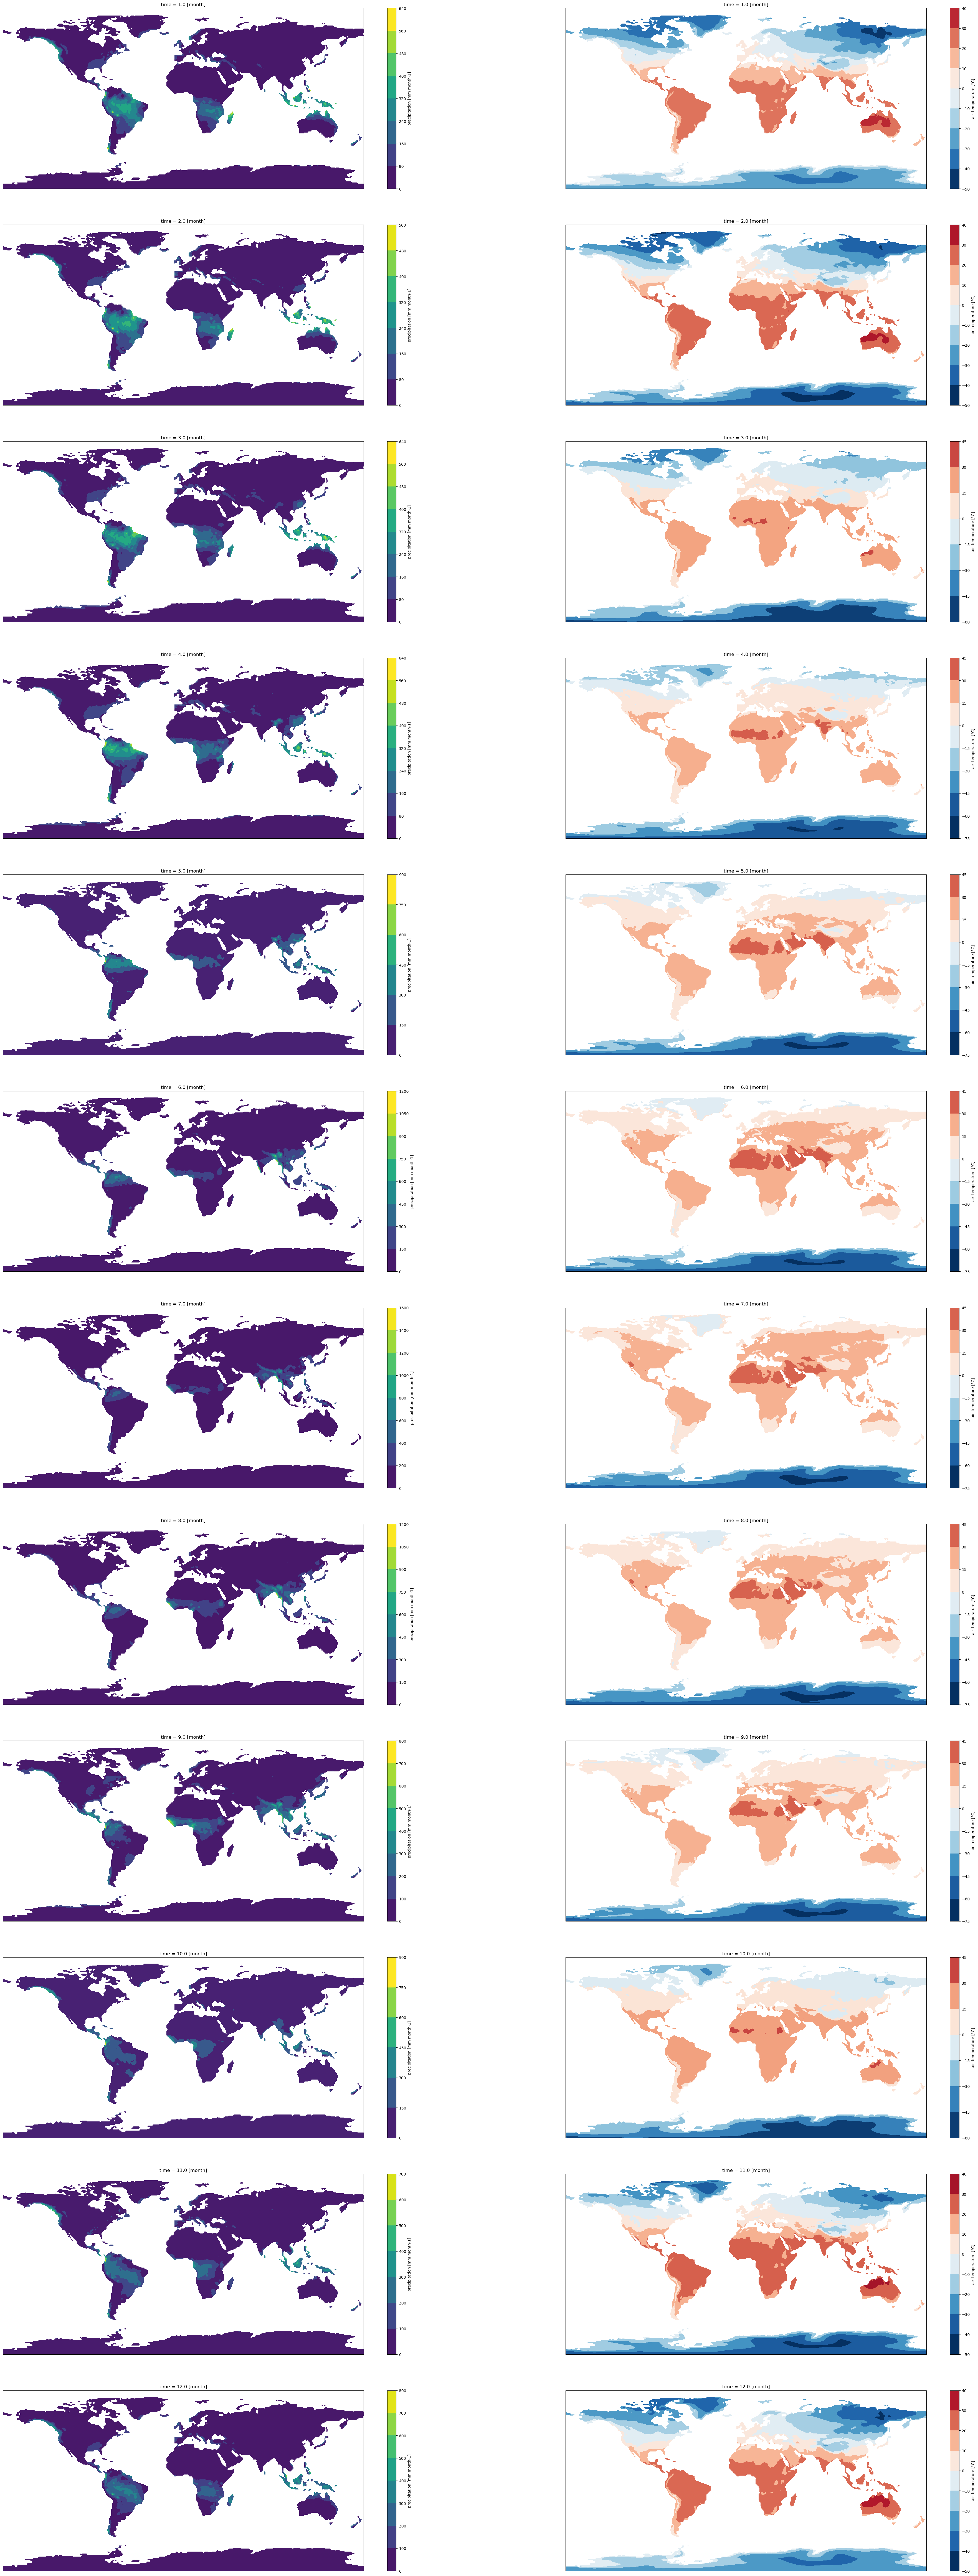

In [36]:
fig1 = matplotlib.pyplot.figure(figsize=(3*16,12*10))

for month in range(12):
    ax1 = fig1.add_subplot(12,2,month*2 +1 ,projection=cartopy.crs.PlateCarree())
    plot_ds = data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_mean'].loc[{'time': month+1}]['precipitation']
    plot_ds.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree()) 

    ax1 = fig1.add_subplot(12,2,month*2 +2 ,projection=cartopy.crs.PlateCarree())
    plot_ds = data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_mean'].loc[{'time': month+1}]['air_temperature']
    plot_ds.plot.contourf(ax=ax1, transform=cartopy.crs.PlateCarree()) 


In [37]:
data_dict[list(time_periods.keys())[0]][historic_scenario_str]['climate_std'].to_dataframe().unstack(['time'])

precipitation                                                  \
time                  1.0     2.0     3.0     4.0     5.0     6.0     7.0    
lat   lon                                                                    
 89.5 -179.5           NaN     NaN     NaN     NaN     NaN     NaN     NaN   
      -178.5           NaN     NaN     NaN     NaN     NaN     NaN     NaN   
      -177.5           NaN     NaN     NaN     NaN     NaN     NaN     NaN   
      -176.5           NaN     NaN     NaN     NaN     NaN     NaN     NaN   
      -175.5           NaN     NaN     NaN     NaN     NaN     NaN     NaN   
...                    ...     ...     ...     ...     ...     ...     ...   
-89.5  175.5        4.1250  4.7500  6.7500  7.0625  7.3125  5.9375  5.9375   
       176.5        4.1250  4.8125  6.8125  7.0625  7.3750  5.9375  5.9375   
       177.5        4.1875  4.8125  6.8125  7.1250  7.4375  6.0000  6.0000   
       178.5        4.1875  4.8125  6.8750  7.1875  7.5000  6.0000  6.0000   
       179.5        4.1250  4.7500  6.6875  7.0000  7.3125  5.8750  5.8750   

                                      ... air_temperature                  \
time            8.0     9.0     10.0  ...            3.0     4.0     5.0    
lat   lon                             ...                                   
 89.5 -179.5     NaN     NaN     NaN  ...             NaN     NaN     NaN   
      -178.5     NaN     NaN     NaN  ...             NaN     NaN     NaN   
      -177.5     NaN     NaN     NaN  ...             NaN     NaN     NaN   
      -176.5     NaN     NaN     NaN  ...             NaN     NaN     NaN   
      -175.5     NaN     NaN     NaN  ...             NaN     NaN     NaN   
...              ...     ...     ...  ...             ...     ...     ...   
-89.5  175.5  2.4375  5.8750  6.2500  ...          1.4375  2.1875  2.6250   
       176.5  2.3750  5.8750  6.3125  ...          1.8125  2.6250  3.0625   
       177.5  2.1875  5.9375  6.3750  ...          2.4375  3.2500  3.6875   
       178.5  2.0625  6.0000  6.3750  ...          3.4375  4.3125  4.7500   
       179.5  2.3750  5.8750  6.2500  ...          6.1250  7.1250  7.5625   

                                                                      
time            6.0     7.0     8.0     9.0     10.0    11.0    12.0  
lat   lon                                                             
 89.5 -179.5     NaN     NaN     NaN     NaN     NaN     NaN     NaN  
      -178.5     NaN     NaN     NaN     NaN     NaN     NaN     NaN  
      -177.5     NaN     NaN     NaN     NaN     NaN     NaN     NaN  
      -176.5     NaN     NaN     NaN     NaN     NaN     NaN     NaN  
      -175.5     NaN     NaN     NaN     NaN     NaN     NaN     NaN  
...              ...     ...     ...     ...     ...     ...     ...  
-89.5  175.5  1.7500  2.1250  2.6250  1.7500  1.2500  2.0000  2.1250  
       176.5  2.1875  2.6250  3.1250  2.2500  1.6875  2.2500  2.3125  
       177.5  2.8750  3.3125  3.8125  2.9375  2.2500  2.6875  2.5625  
       178.5  4.0000  4.5000  4.9375  4.1250  3.2500  3.3750  3.0625  
       179.5  6.9375  7.4375  7.8750  7.1250  5.9375  5.2500  4.4375  

[64800 rows x 24 columns]

In [78]:
def create_dataframe_period(data_period_scenario, period, scenario):
    df_mean = data_period_scenario['climate_mean'].to_dataframe().unstack(['time'])
    df_mean.columns = ['_'.join(map(str,l1))+ '_mean' for l1 in df_mean.columns]
    df_mean = df_mean.reset_index()
    
    df_std = data_period_scenario['climate_mean'].to_dataframe().unstack(['time'])
    df_std.columns = ['_'.join(map(str,l1)) + '_std' for l1 in df_std.columns]
    df_std = df_std.reset_index()
    
    df_zone = data_period_scenario['climate_zone']['kg_class'].to_dataframe()
    df_zone = df_std.reset_index()

    df_climate_zones = df_mean.merge(df_std, on=['lat','lon'])
    df_climate_zones = df_climate_zones.merge(df_zone, on=['lat','lon'])
    df_climate_zones = df_climate_zones[~df_climate_zones['precipitation_1.0_mean'].isna()]
    df_climate_zones['period_start'] = period[0]
    df_climate_zones['period_end'] = period[1] 
    df_climate_zones['scenario'] = scenario
    # df_climate_zones = df_climate_zones.reset_index()
    return df_climate_zones

In [79]:
current_scenario = historic_scenario_str
current_period = list(time_periods.keys())[0]
df_period_scenario = create_dataframe_period(data_dict[current_period][current_scenario], current_period, current_scenario)
df_period_scenario

,lat,lon,precipitation_1.0_mean,precipitation_2.0_mean,precipitation_3.0_mean,precipitation_4.0_mean,precipitation_5.0_mean,precipitation_6.0_mean,precipitation_7.0_mean,precipitation_8.0_mean,...,air_temperature_6.0_std_y,air_temperature_7.0_std_y,air_temperature_8.0_std_y,air_temperature_9.0_std_y,air_temperature_10.0_std_y,air_temperature_11.0_std_y,air_temperature_12.0_std_y,period_start,period_end,scenario
2301,83.5,-38.5,12.1250,8.2500,8.9375,21.8750,15.5000,29.8750,35.8750,46.1250,...,-3.5000,0.3750,-2.3125,-11.1875,-20.8125,-27.0625,-29.5625,1901,1930,historic
2302,83.5,-37.5,10.8750,8.1250,8.6250,19.6250,13.8125,26.8750,32.0625,42.0000,...,-4.4375,-0.5625,-3.2500,-11.8750,-21.4375,-27.6250,-30.0000,1901,1930,historic
2303,83.5,-36.5,9.9375,8.4375,8.8125,18.1250,12.3750,23.6875,28.5000,37.8125,...,-4.3750,-0.6250,-3.1875,-11.9375,-21.5625,-27.8125,-30.1250,1901,1930,historic
2304,83.5,-35.5,10.0000,8.8750,9.0625,17.6250,12.0000,22.4375,26.9375,35.9375,...,-4.8125,-1.2500,-3.7500,-12.3750,-22.0000,-28.1875,-30.3750,1901,1930,historic
2305,83.5,-34.5,10.1250,9.1875,9.4375,16.7500,11.3750,20.6250,24.9375,33.3750,...,-4.3750,-0.6875,-3.3125,-12.6250,-22.4375,-28.8125,-31.0000,1901,1930,historic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64795,-89.5,175.5,4.1250,4.8125,6.7500,7.0625,7.3750,5.9375,5.9375,9.0000,...,-53.7500,-55.1875,-55.7500,-54.5000,-47.4375,-35.6250,-27.1875,1901,1930,historic
64796,-89.5,176.5,4.1250,4.8125,6.8125,7.0625,7.4375,5.9375,6.0000,9.1250,...,-53.4375,-54.8750,-55.3750,-54.1875,-47.1250,-35.3750,-27.0000,1901,1930,historic
64797,-89.5,177.5,4.1875,4.8750,6.8125,7.1250,7.4375,6.0000,6.0000,9.3750,...,-52.9375,-54.3750,-54.8750,-53.7500,-46.6875,-35.0625,-26.6875,1901,1930,historic
64798,-89.5,178.5,4.1875,4.8750,6.8750,7.1875,7.5000,6.0625,6.0625,9.6875,...,-52.1250,-53.5625,-54.0000,-52.8750,-46.0000,-34.5000,-26.2500,1901,1930,historic


todo:
* process all data
* merge into a single data frame of all periods and scenarios
* write out to csv file
* rename to data prep notebook
* create a separate data exploration notebook
* look at distributions for diffent variables in different periods
* for training train supervised and unsupervised (clusters to find types)
* for supervised, training with 5 and 30 class targets
* train and all and a few and compare results of current and future climate
* cosider different train test split strategies (random, by lat.lon


<Axes: ylabel='Frequency'>

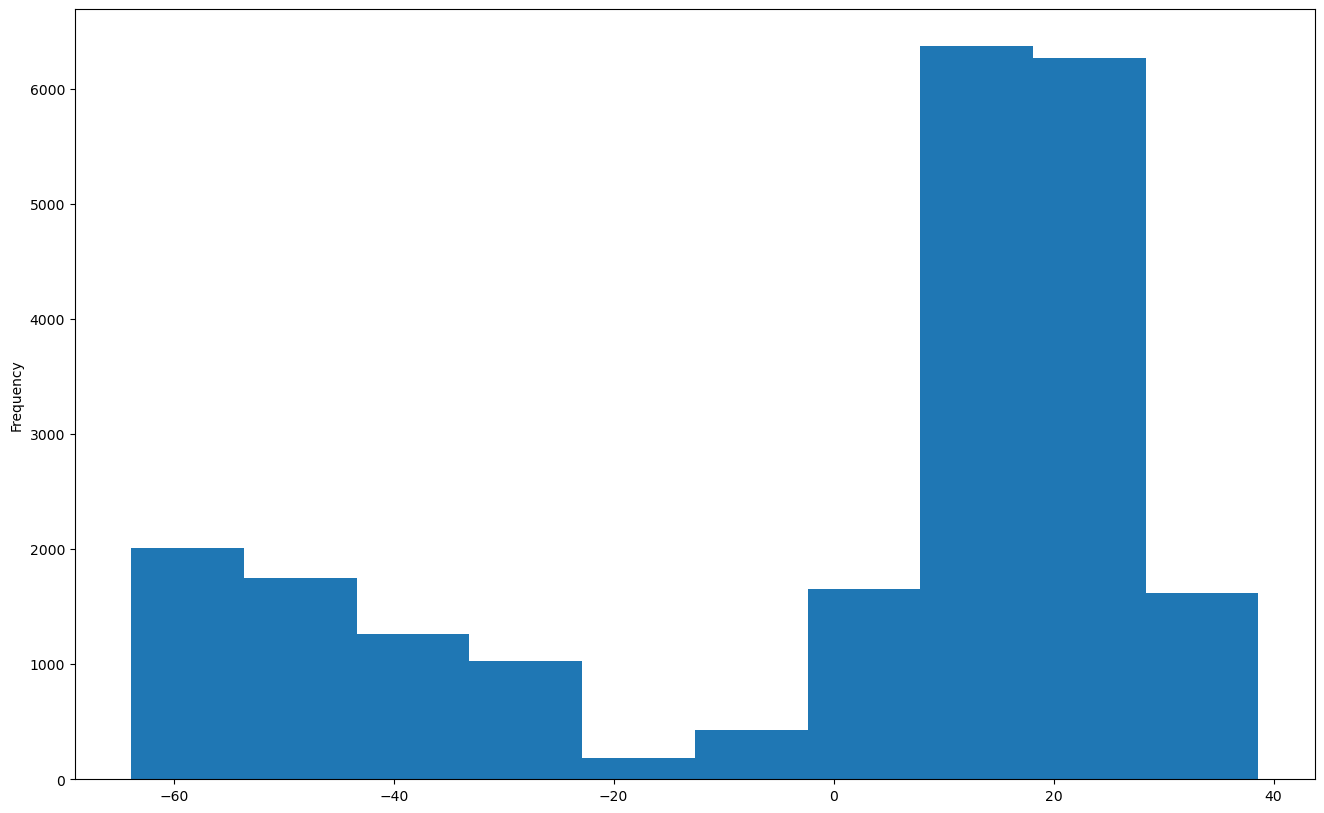

In [64]:
df_period_scenario['air_temperature_7.0_mean'].plot.hist(figsize=(16,10))

In [57]:
df1['precipitation_4.0'].isna().value_counts()

precipitation_4.0
True     42217
False    22583
Name: count, dtype: int64

In [54]:
df1[~df1['precipitation_4.0'].isna()]

,lat,lon,precipitation_1.0,precipitation_2.0,precipitation_3.0,precipitation_4.0,precipitation_5.0,precipitation_6.0,precipitation_7.0,precipitation_8.0,...,air_temperature_3.0,air_temperature_4.0,air_temperature_5.0,air_temperature_6.0,air_temperature_7.0,air_temperature_8.0,air_temperature_9.0,air_temperature_10.0,air_temperature_11.0,air_temperature_12.0
2301,83.5,-38.5,12.1250,8.2500,8.9375,21.8750,15.5000,29.8750,35.8750,46.1250,...,-33.3125,-25.1250,-12.7500,-3.5000,0.3750,-2.3125,-11.1875,-20.8125,-27.0625,-29.5625
2302,83.5,-37.5,10.8750,8.1250,8.6250,19.6250,13.8125,26.8750,32.0625,42.0000,...,-33.7500,-25.7500,-13.5625,-4.4375,-0.5625,-3.2500,-11.8750,-21.4375,-27.6250,-30.0000
2303,83.5,-36.5,9.9375,8.4375,8.8125,18.1250,12.3750,23.6875,28.5000,37.8125,...,-33.8750,-25.8750,-13.5625,-4.3750,-0.6250,-3.1875,-11.9375,-21.5625,-27.8125,-30.1250
2304,83.5,-35.5,10.0000,8.8750,9.0625,17.6250,12.0000,22.4375,26.9375,35.9375,...,-34.0625,-26.1875,-13.9375,-4.8125,-1.2500,-3.7500,-12.3750,-22.0000,-28.1875,-30.3750
2305,83.5,-34.5,10.1250,9.1875,9.4375,16.7500,11.3750,20.6250,24.9375,33.3750,...,-34.2500,-26.3750,-13.8750,-4.3750,-0.6875,-3.3125,-12.6250,-22.4375,-28.8125,-31.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64795,-89.5,175.5,4.1250,4.8125,6.7500,7.0625,7.3750,5.9375,5.9375,9.0000,...,-48.4375,-52.8125,-53.6250,-53.7500,-55.1875,-55.7500,-54.5000,-47.4375,-35.6250,-27.1875
64796,-89.5,176.5,4.1250,4.8125,6.8125,7.0625,7.4375,5.9375,6.0000,9.1250,...,-48.1250,-52.5000,-53.2500,-53.4375,-54.8750,-55.3750,-54.1875,-47.1250,-35.3750,-27.0000
64797,-89.5,177.5,4.1875,4.8750,6.8125,7.1250,7.4375,6.0000,6.0000,9.3750,...,-47.6250,-52.0000,-52.7500,-52.9375,-54.3750,-54.8750,-53.7500,-46.6875,-35.0625,-26.6875
64798,-89.5,178.5,4.1875,4.8750,6.8750,7.1875,7.5000,6.0625,6.0625,9.6875,...,-46.8750,-51.1875,-51.9375,-52.1250,-53.5625,-54.0000,-52.8750,-46.0000,-34.5000,-26.2500


In [41]:
df1 = df1.reset_index()
df1

,lat,lon,precipitation_1.0,precipitation_2.0,precipitation_3.0,precipitation_4.0,precipitation_5.0,precipitation_6.0,precipitation_7.0,precipitation_8.0,...,air_temperature_3.0,air_temperature_4.0,air_temperature_5.0,air_temperature_6.0,air_temperature_7.0,air_temperature_8.0,air_temperature_9.0,air_temperature_10.0,air_temperature_11.0,air_temperature_12.0
0,89.5,-179.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,89.5,-178.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,89.5,-177.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,89.5,-176.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,89.5,-175.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64795,-89.5,175.5,4.1250,4.8125,6.7500,7.0625,7.3750,5.9375,5.9375,9.0000,...,-48.4375,-52.8125,-53.6250,-53.7500,-55.1875,-55.7500,-54.5000,-47.4375,-35.6250,-27.1875
64796,-89.5,176.5,4.1250,4.8125,6.8125,7.0625,7.4375,5.9375,6.0000,9.1250,...,-48.1250,-52.5000,-53.2500,-53.4375,-54.8750,-55.3750,-54.1875,-47.1250,-35.3750,-27.0000
64797,-89.5,177.5,4.1875,4.8750,6.8125,7.1250,7.4375,6.0000,6.0000,9.3750,...,-47.6250,-52.0000,-52.7500,-52.9375,-54.3750,-54.8750,-53.7500,-46.6875,-35.0625,-26.6875
64798,-89.5,178.5,4.1875,4.8750,6.8750,7.1875,7.5000,6.0625,6.0625,9.6875,...,-46.8750,-51.1875,-51.9375,-52.1250,-53.5625,-54.0000,-52.8750,-46.0000,-34.5000,-26.2500


In [42]:
df2.reset_index()
df2

kg_class
lat   lon             
 89.5 -179.5       0.0
      -178.5       0.0
      -177.5       0.0
      -176.5       0.0
      -175.5       0.0
...                ...
-89.5  175.5      30.0
       176.5      30.0
       177.5      30.0
       178.5      30.0
       179.5      30.0

[64800 rows x 1 columns]

In [ ]:
# create grouped zones column

In [ ]:
import sklearn


In [ ]:
#predictors and target data frames

In [ ]:
# train test split

In [ ]:
# normalise data

In [ ]:
# train decision tree, random forest etc.

## Exercises
for students to try that do not have solutions but maybe have an answer or benchmark to facilitate understanding


### Next steps or potential follow on material



###  Exmaples of Use


### Data statement
###     References
